In [5]:
import sys
!{sys.executable} -m pip install imbalanced-learn shap xgboost mlflow --quiet

# Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import mlflow.xgboost
import shap

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, recall_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

f:\Projects\employee_resgination\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load & Explore

In [7]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(df.shape)
print(df.info())
print(df['Attrition'].value_counts())

(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

# Phase 2: Feature Engineering

In [8]:
df.drop(['EmployeeCount', 'Over18', 'StandardHours'], axis=1, inplace=True, errors='ignore')

# Encode binary columns
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})          # ✅ was missing
df['BusinessTravel'] = df['BusinessTravel'].map({                  # ✅ was missing
    'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2
})

# One-hot encode multi-category columns
df = pd.get_dummies(df, columns=['Department', 'JobRole', 'MaritalStatus'], dtype=int)

# New features
df['SatisfactionScore'] = (
    df['JobSatisfaction'] + df['EnvironmentSatisfaction'] + df['RelationshipSatisfaction']
) / 3
df['IncomePerYear'] = df['MonthlyIncome'] * 12 / (df['YearsAtCompany'] + 1)


In [9]:
df = pd.get_dummies(
    df,
    columns=['EducationField'],
    drop_first=True
)

# Train/Test Split + SMOTE

In [10]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Model 1: Logistic Regression (baseline)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)
print("LR AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]))

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)
print("RF AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))


f:\Projects\employee_resgination\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR AUC: 0.6767163407700921
RF AUC: 0.7487725040916531


#  XGBoost + Evaluation + MLflow

f:\Projects\employee_resgination\venv\Lib\site-packages\xgboost\core.py:160: UserWarning: [19:27:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
  warnings.warn(smsg, UserWarning)
Registered model 'AttritionModel' already exists. Creating a new version of this model...
Created version '2' of model 'AttritionModel'.


              precision    recall  f1-score   support

           0       0.89      0.94      0.92       247
           1       0.56      0.38      0.46        47

    accuracy                           0.85       294
   macro avg       0.73      0.66      0.69       294
weighted avg       0.84      0.85      0.84       294

AUC-ROC: 0.7652683262985615


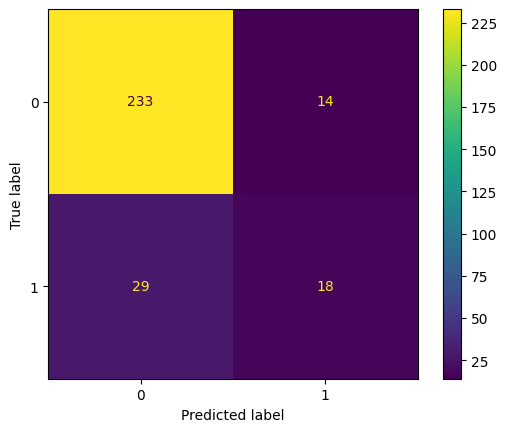

In [11]:
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

mlflow.set_experiment("employee-attrition")

with mlflow.start_run(run_name="xgboost-smote"):
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("smote", True)

    xgb.fit(X_train_res, y_train_res)              # fit ONCE

    y_pred = xgb.predict(X_test)
    y_prob = xgb.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    rec = recall_score(y_test, y_pred)

    mlflow.log_metric("auc_roc", auc)
    mlflow.log_metric("recall_attrition", rec)
    mlflow.xgboost.log_model(xgb, "model", registered_model_name="AttritionModel")

    print(classification_report(y_test, y_pred))
    print("AUC-ROC:", auc)
    ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test)
    plt.show()


# Save model for app.py

In [12]:
joblib.dump(xgb, 'xgb_model.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')
print("✅ xgb_model.pkl saved")
print("✅ feature_columns.pkl saved")

✅ xgb_model.pkl saved
✅ feature_columns.pkl saved


# SHAP

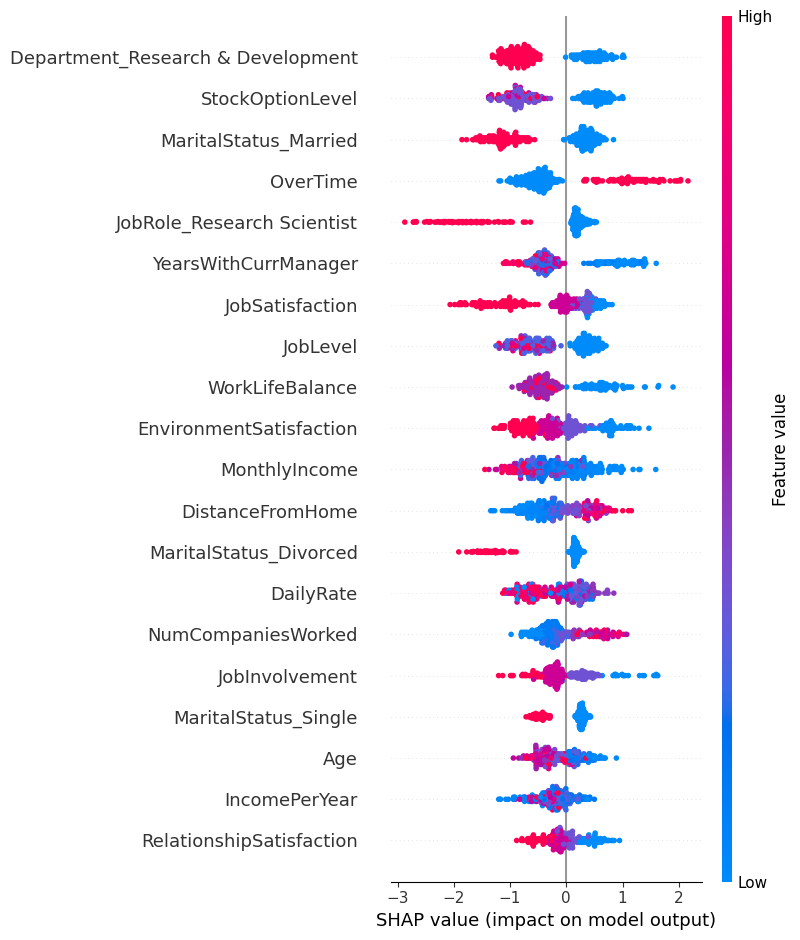

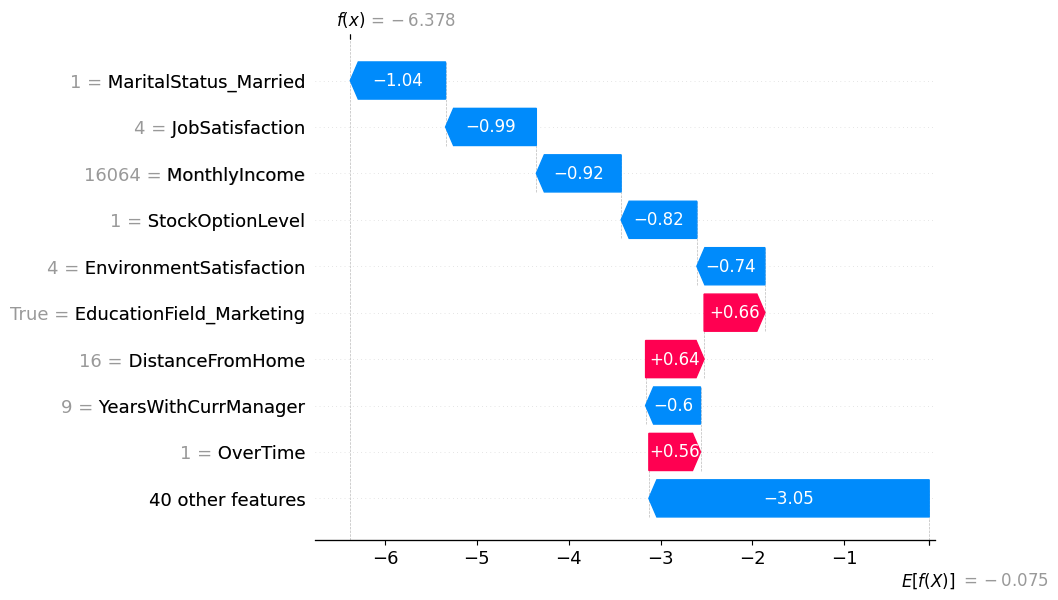

In [13]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Global: which features matter most?
shap.summary_plot(shap_values, X_test)

# Local: why is the top at-risk employee flagged?
shap_explanation = explainer(X_test)
shap.plots.waterfall(shap_explanation[42])